In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score



### Wczytanie danych i podstawowa analiza

In [66]:
dataset = fetch_ucirepo(id=365)
X = dataset.data.features
y = dataset.data.targets

In [67]:
df = X.copy()
df['class'] = y['class']

In [68]:
df

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
0,1,0.20,0.38,0.40,2.05,32.35,0.39,0.25,1.33,1.14,...,0.12,0.40,0.88,0.00,8.42,5.14,82.66,4.42,7.43,0
1,1,0.21,0.50,0.47,1.94,14.79,0.00,0.26,1.00,1.70,...,0.12,0.42,0.85,0.00,4.15,3.27,107.35,3.40,60.99,0
2,1,0.25,0.70,0.27,1.55,-1.15,0.00,0.31,0.44,1.31,...,0.24,0.82,0.77,0.69,4.99,3.95,134.27,2.72,5.21,0
3,1,0.08,0.31,0.46,2.49,51.95,0.15,0.09,1.87,1.06,...,0.05,0.14,0.95,0.00,4.57,3.61,86.44,4.22,5.55,0
4,1,0.19,0.61,0.23,1.41,-7.31,0.19,0.19,0.63,1.16,...,0.13,0.48,0.87,0.12,6.40,4.32,127.21,2.87,7.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43400,5,0.01,0.71,0.04,1.17,-18.91,0.00,0.01,0.42,1.68,...,0.02,0.04,1.01,1.26,13.47,12.43,49.12,7.43,2.28,1
43401,5,-0.58,0.97,-0.80,0.17,-67.36,-0.58,-0.58,-0.40,0.94,...,-0.06,1.48,1.06,-0.02,110.72,44.76,81.22,4.49,5.13,1
43402,5,-0.18,1.26,-0.28,0.75,-120.44,-0.18,-0.15,-0.26,1.17,...,0.15,0.55,0.85,-0.52,9.85,3.49,207.87,1.76,9.95,1
43403,5,-0.11,0.74,0.02,1.09,-17.00,-0.11,-0.11,0.13,0.85,...,-0.18,-1.17,1.18,6.09,13.89,6.08,83.12,4.39,0.96,1


In [69]:
print(f"Full dataset shape: {df.shape}")
print(f"Years available: {sorted(df['year'].unique())}")
print()

for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]
    n = len(subset)
    n_bankrupt = (subset['class'] == 1).sum()
    n_missing = subset.drop(columns=['class']).isnull().sum().sum()
    n_cells = subset.drop(columns=['class', 'year']).size
    print(f"Year {year}: {n} rows, "
          f"bankrupt {n_bankrupt} ({100*n_bankrupt/n:.1f}%), "
          f"missing {n_missing} ({100*n_missing/n_cells:.1f}% cells)")

Full dataset shape: (43405, 66)
Years available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Year 1: 7027 rows, bankrupt 271 (3.9%), missing 5835 (1.3% cells)
Year 2: 10173 rows, bankrupt 400 (3.9%), missing 12157 (1.9% cells)
Year 3: 10503 rows, bankrupt 495 (4.7%), missing 9888 (1.5% cells)
Year 4: 9792 rows, bankrupt 515 (5.3%), missing 8776 (1.4% cells)
Year 5: 5910 rows, bankrupt 410 (6.9%), missing 4666 (1.2% cells)


wybieramy Year 4 

Shape: (9792, 64)
Bankrupt: 515 (5.3%)
Not bankrupt: 9277 (94.7%)

Missing values: 8776 (1.4% cells)


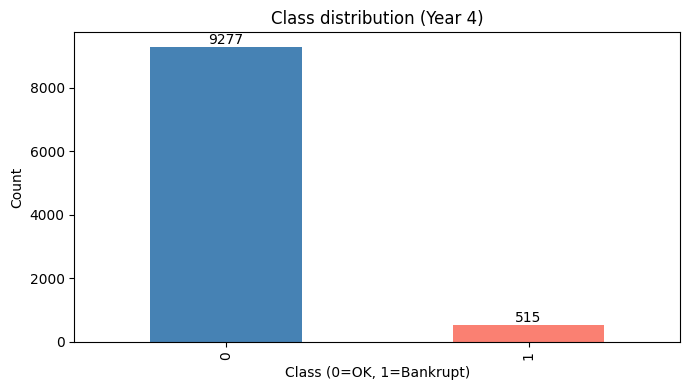

In [70]:
df = X.copy()
df['class'] = y['class']
df = df[df['year'] == 4].drop(columns=['year'])

X = df.drop(columns=['class'])
y = df['class']
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

bankrupt = (y == 1).sum()
not_bankrupt = (y == 0).sum()
missing_cells = X.isnull().sum().sum()
total_cells = X.size

print(f"Shape: {X.shape}")
print(f"Bankrupt: {bankrupt} ({100*bankrupt/len(y):.1f}%)")
print(f"Not bankrupt: {not_bankrupt} ({100*not_bankrupt/len(y):.1f}%)")
print(f"\nMissing values: {missing_cells} ({100*missing_cells/total_cells:.1f}% cells)")

fig, ax = plt.subplots(figsize=(7, 4))
y.value_counts().sort_index().plot.bar(ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Class distribution (Year 4)')
ax.set_xlabel('Class (0=OK, 1=Bankrupt)')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [71]:
pd.set_option('display.float_format', '{:.2f}'.format)

desc = X.describe().T
desc['missing_%'] = (X.isnull().sum() / len(X) * 100).round(1)

print(desc[['mean', 'std', 'min', '50%', 'max', 'missing_%']].to_string())

       mean       std         min    50%         max  missing_%
A1     0.04      0.36      -12.46   0.04       20.48       0.00
A2     0.60      4.59        0.00   0.47      446.91       0.00
A3     0.13      4.56     -445.91   0.20       22.77       0.00
A4     8.14    290.65       -0.05   1.59    27146.00       0.40
A5    64.26  14732.27  -379000.00  -0.06  1030000.00       0.20
A6    -0.06      6.81     -486.82   0.00      322.20       0.00
A7     0.06      0.53      -12.46   0.05       38.62       0.00
A8    19.88    698.70       -1.85   1.09    53209.00       0.20
A9     1.88     17.67       -0.03   1.16     1704.80       0.00
A10    0.39      4.59     -445.91   0.51       12.60       0.00
A11    0.08      0.53      -12.24   0.06       38.62       0.00
A12    0.21     74.24    -6331.80   0.14     3340.90       0.40
A13    0.40     37.97    -1460.60   0.06     2707.70       0.20
A14    0.06      0.53      -12.46   0.05       38.62       0.00
A15 3018.65 102317.01 -1570000.00 906.56

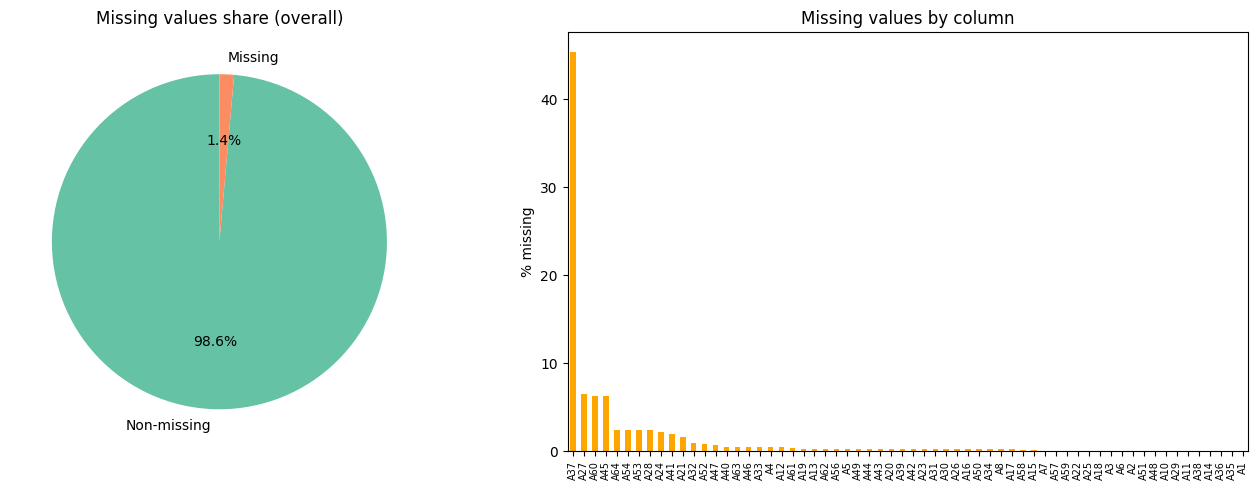

In [72]:
missing_cells = X.isnull().sum().sum()
total_cells = X.size
non_missing_cells = total_cells - missing_cells

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values overall
axes[0].pie(
    [non_missing_cells, missing_cells],
    labels=['Non-missing', 'Missing'],
    colors=['#66c2a5', '#fc8d62'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Missing values share (overall)')

# Missing values per column
missing = (X.isnull().sum() / len(X) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
missing.plot.bar(ax=axes[1], color='orange')
axes[1].set_title('Missing values by column')
axes[1].set_ylabel('% missing')
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()

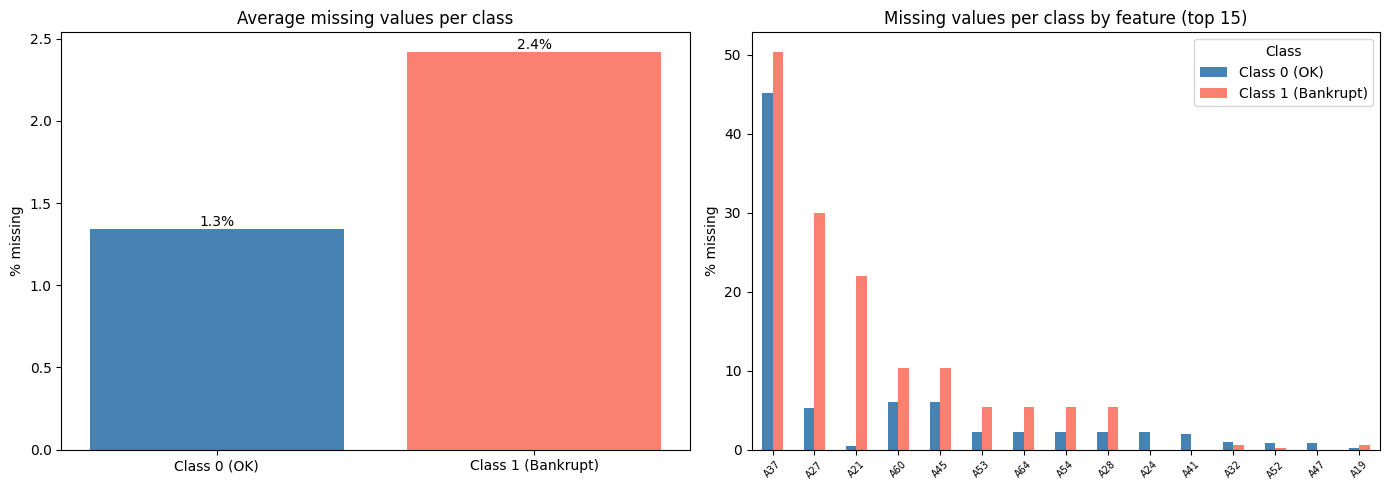

In [73]:
# Percent missing per feature in each class
y_series = y.squeeze()

missing_per_class = (
    (X.isnull().groupby(y_series).mean().T * 100)
    .rename(columns={0: 'Class 0 (OK)', 1: 'Class 1 (Bankrupt)'})
)

missing_summary = pd.DataFrame({
    'Class 0 (OK)': [missing_per_class['Class 0 (OK)'].mean()],
    'Class 1 (Bankrupt)': [missing_per_class['Class 1 (Bankrupt)'].mean()]
}, index=['Average missing % across features'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

left_vals = missing_summary.iloc[0]
left_labels = left_vals.index.tolist()
left_colors = ['steelblue', 'salmon']
axes[0].bar(left_labels, left_vals.values, color=left_colors)
axes[0].set_title('Average missing values per class')
axes[0].set_ylabel('% missing')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

top_missing_features = (
    missing_per_class.mean(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)
missing_per_class.loc[top_missing_features].plot.bar(
    ax=axes[1],
    color=['steelblue', 'salmon']
 )
axes[1].set_title('Missing values per class by feature (top 15)')
axes[1].set_ylabel('% missing')
axes[1].tick_params(axis='x', labelsize=7, rotation=45)
axes[1].legend(title='Class')

plt.tight_layout()
plt.show()

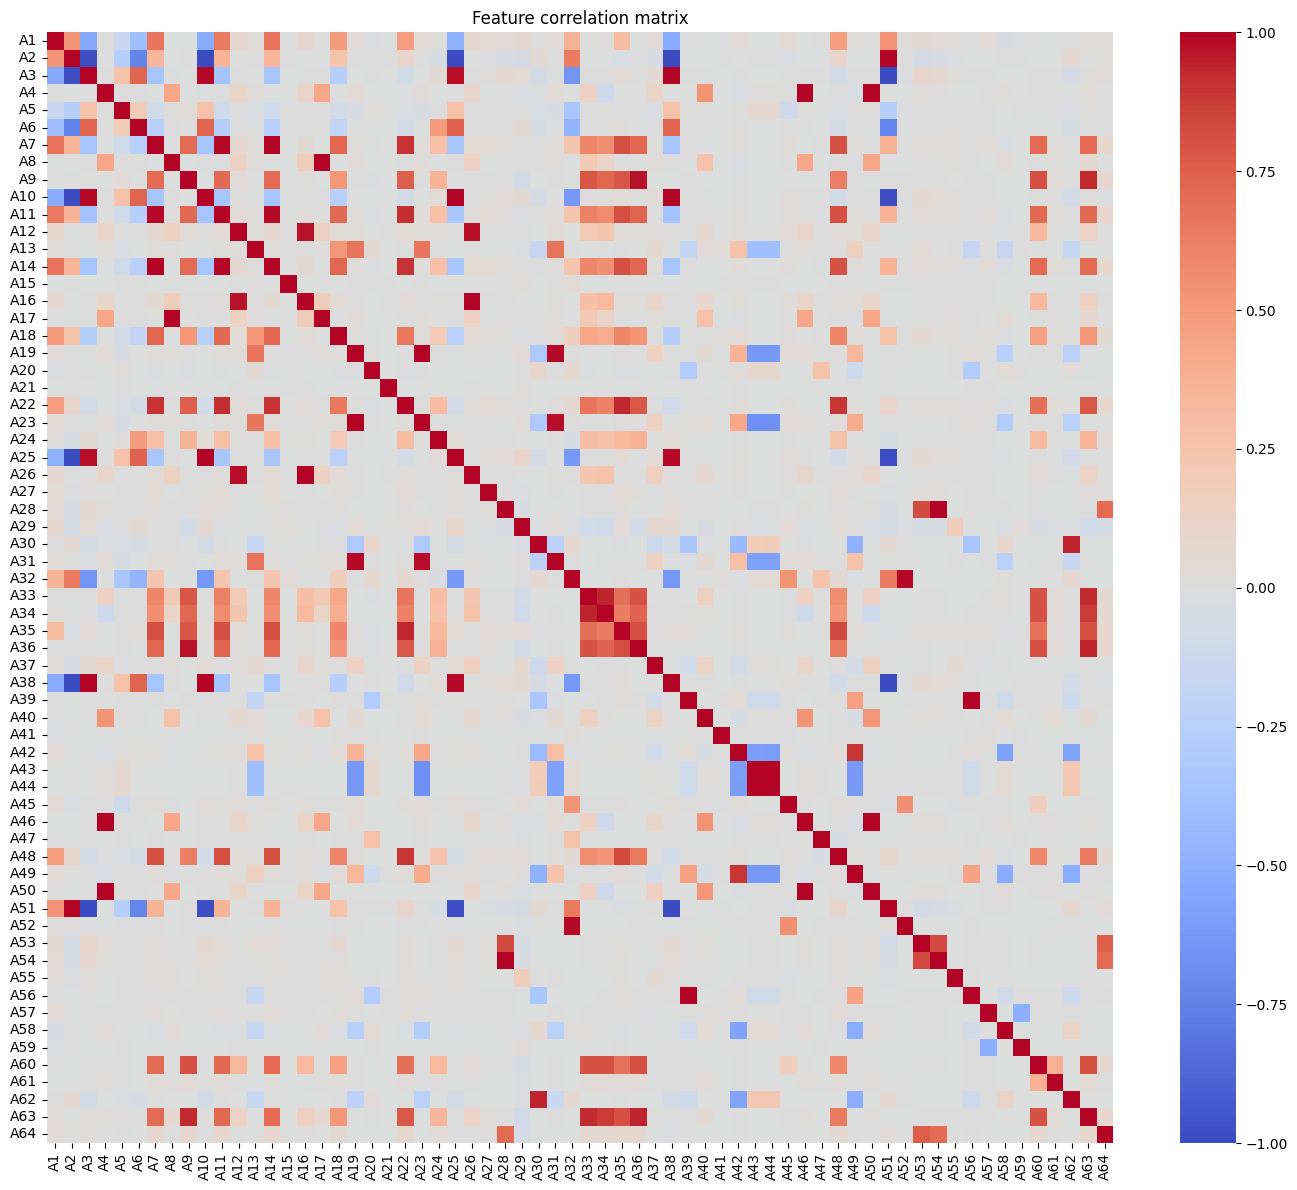

In [74]:
corr = X.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, linewidths=0)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

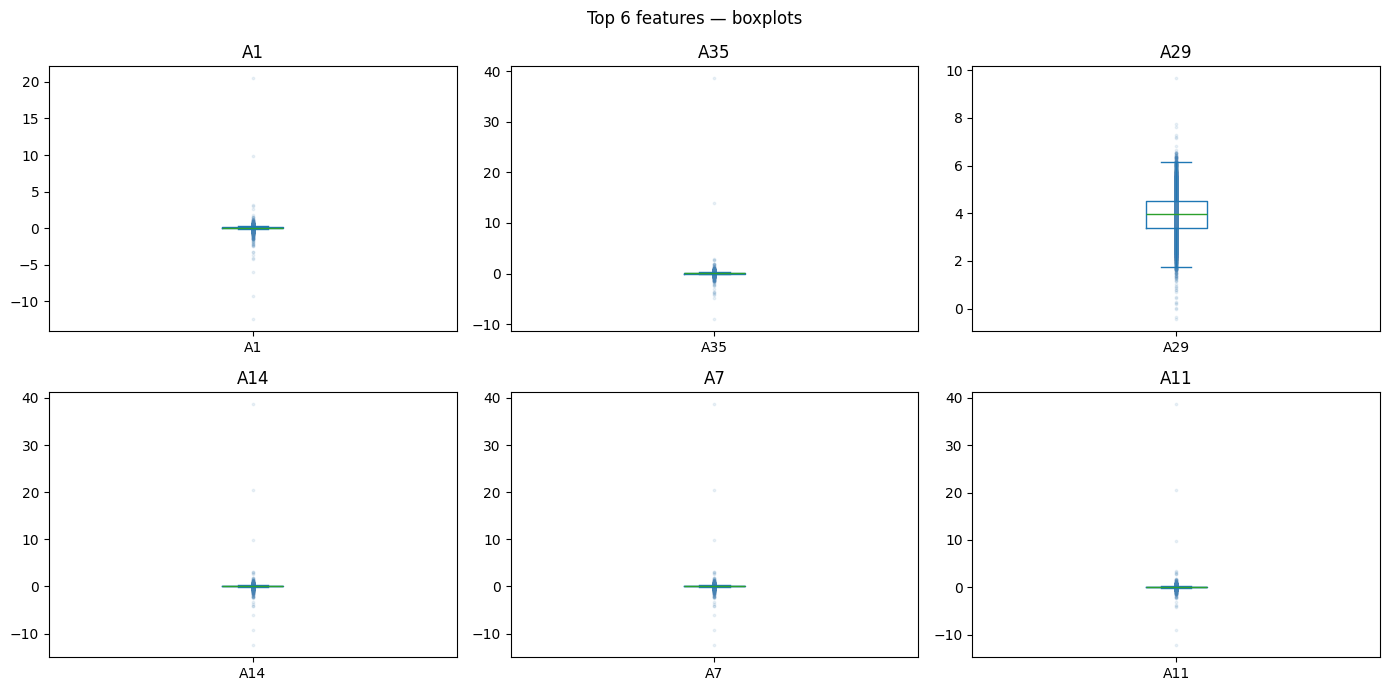

In [75]:
correlations = X.corrwith(y).abs().sort_values(ascending=False)
sample_cols = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), sample_cols):
    X[col].plot.box(ax=ax, showfliers=False)
    ax.scatter([1] * len(X[col]), X[col], alpha=0.1, s=3, color='steelblue')
    ax.set_title(col)

plt.suptitle('Top 6 features — boxplots')
plt.tight_layout()
plt.show()

Usuwamy A37, bo przy 45% braków imputacja medianą stworzyłaby sztuczny rozkład, a informację o płynności pokrywają inne kolumny (A46, A50, A4).

In [76]:
X = X.drop(columns=['A37'])
print("Shape after dropping A37:", X.shape)
print("Remaining missing:", X.isnull().sum().sum())

Shape after dropping A37: (9792, 63)
Remaining missing: 4334


In [77]:
missing_per_row = X.isnull().sum(axis=1)

print("Rows with any missing value:", (missing_per_row > 0).sum(), f"({100*(missing_per_row > 0).mean():.2f}%)")
print()
print("Avg missing features per row:")
print(f"  Class 0 (OK):       {missing_per_row[y==0].mean():.2f}")
print(f"  Class 1 (Bankrupt): {missing_per_row[y==1].mean():.2f}")

Rows with any missing value: 1701 (17.37%)

Avg missing features per row:
  Class 0 (OK):       0.41
  Class 1 (Bankrupt): 1.04


### Uzupełnianie braków

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows, bankrupt: {(y_train==1).sum()} ({100*(y_train==1).mean():.1f}%)")
print(f"Test:  {X_test.shape[0]} rows, bankrupt: {(y_test==1).sum()} ({100*(y_test==1).mean():.1f}%)")

X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

Train: 7833 rows, bankrupt: 412 (5.3%)
Test:  1959 rows, bankrupt: 103 (5.3%)


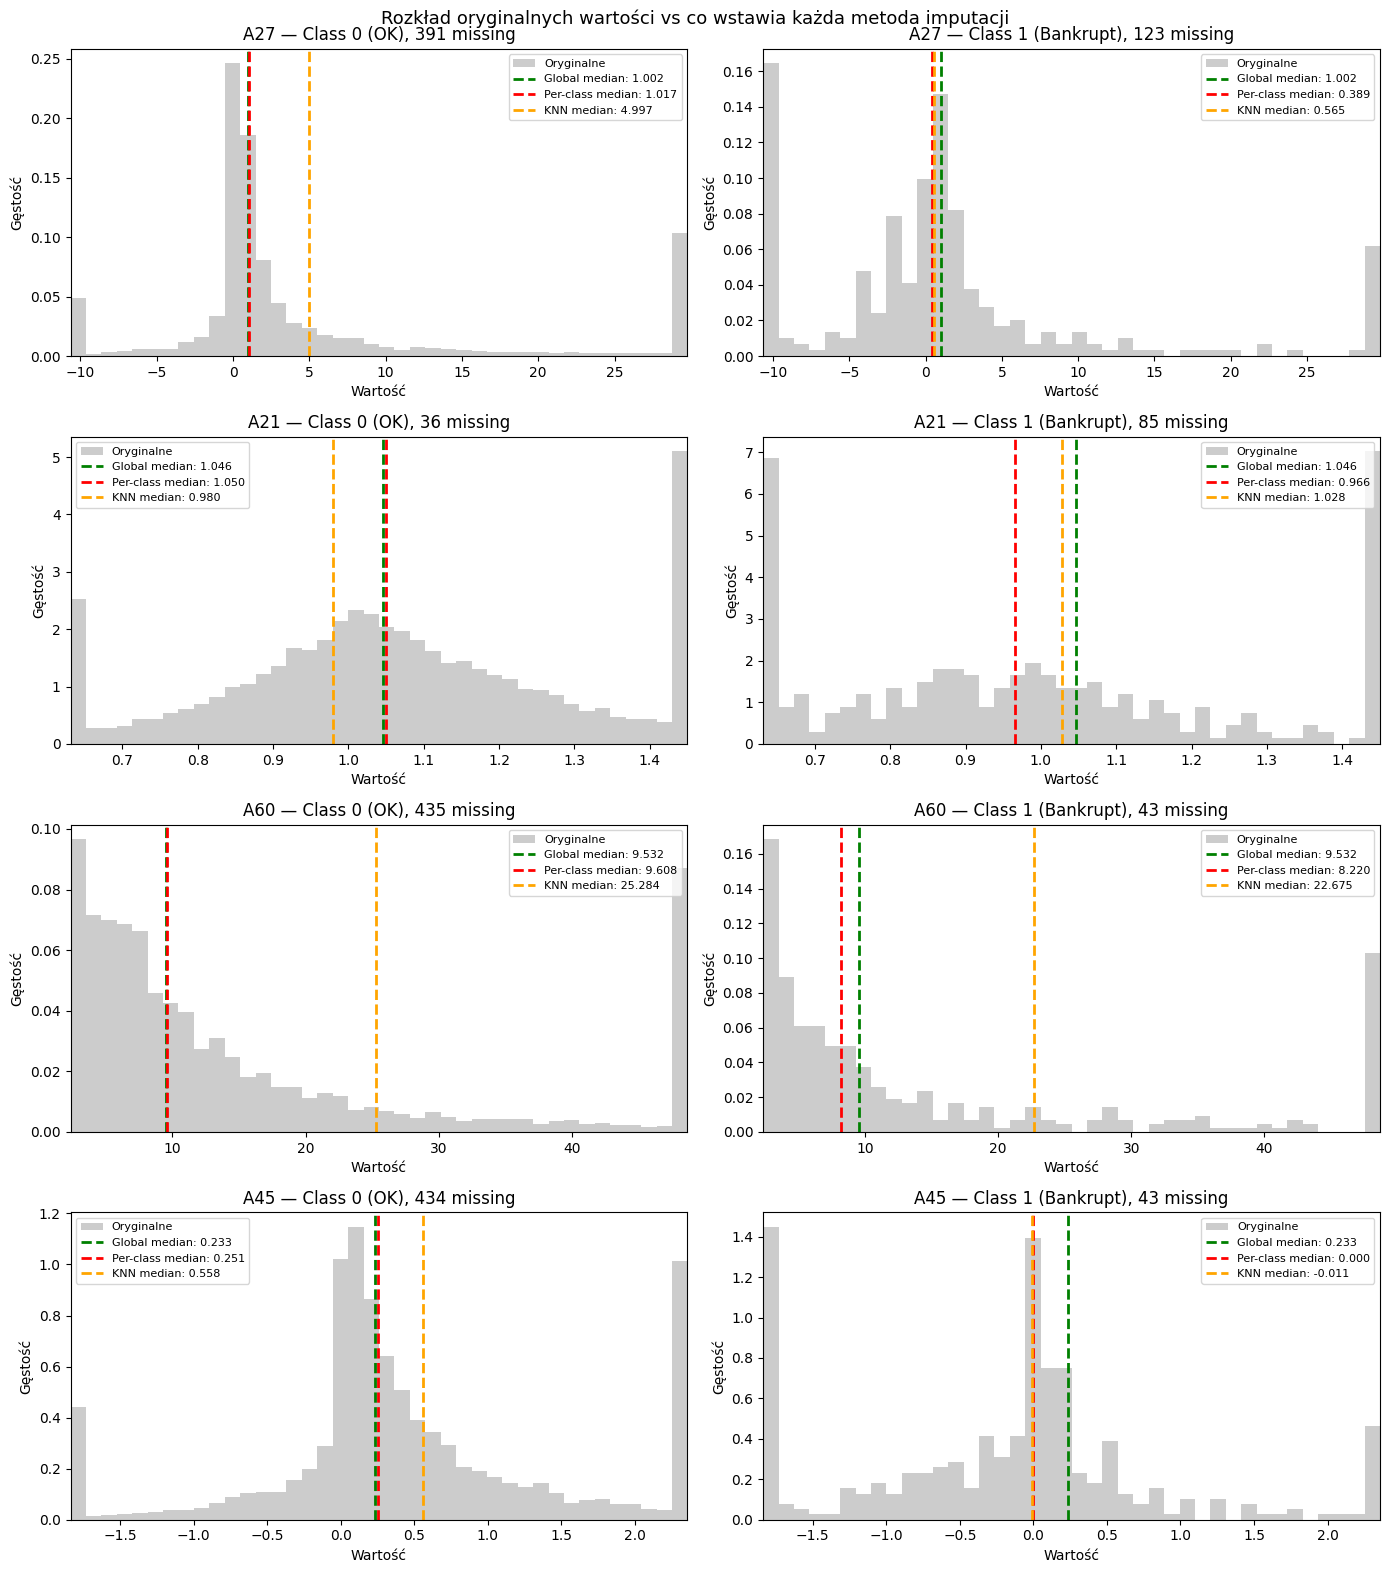

In [79]:
from sklearn.impute import KNNImputer

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

focus_cols = ['A27', 'A21', 'A60', 'A45']

# --- 3 metody imputacji ---
imp_global = SimpleImputer(strategy='median')
X_global = pd.DataFrame(imp_global.fit_transform(X_train), columns=X_train.columns)

X_per_class = X_train.copy()
for col in X_train.columns:
    for cls in [0, 1]:
        mask = pd.Series(y_train.values == cls, index=X_train.index)
        col_median = X_train.loc[mask, col].median()
        X_per_class.loc[mask & X_per_class[col].isna(), col] = col_median

imp_knn = KNNImputer(n_neighbors=5)
X_knn = pd.DataFrame(imp_knn.fit_transform(X_train), columns=X_train.columns)

# --- Wykres ---
fig, axes = plt.subplots(len(focus_cols), 2, figsize=(14, 4 * len(focus_cols)))

for row_idx, col in enumerate(focus_cols):
    missing_mask = X_train[col].isna()

    # Wspólna skala dla obu klas — percentyle z całej kolumny
    all_original = X_train.loc[~missing_mask, col]
    lo, hi = all_original.quantile(0.05), all_original.quantile(0.90)

    for cls_idx, (cls, cls_label) in enumerate([(0, 'OK'), (1, 'Bankrupt')]):
        cls_mask = pd.Series(y_train.values == cls, index=X_train.index)
        was_missing = missing_mask & cls_mask

        ax = axes[row_idx, cls_idx]

        original = X_train.loc[~missing_mask & cls_mask, col]
        original_clipped = original.clip(lo, hi)

        ax.hist(original_clipped, bins=40, alpha=0.4, label='Oryginalne', color='gray', density=True)

        for val, color, label in [
            (X_global.loc[was_missing, col].median(), 'green', 'Global median'),
            (X_per_class.loc[was_missing, col].median(), 'red', 'Per-class median'),
            (X_knn.loc[was_missing, col].median(), 'orange', 'KNN median'),
        ]:
            if pd.notna(val):
                ax.axvline(val, color=color, linewidth=2, linestyle='--', label=f'{label}: {val:.3f}')

        ax.set_xlim(lo, hi)
        ax.set_title(f'{col} — Class {cls} ({cls_label}), {was_missing.sum()} missing')
        ax.set_xlabel('Wartość')
        ax.set_ylabel('Gęstość')
        ax.legend(fontsize=8)

plt.suptitle('Rozkład oryginalnych wartości vs co wstawia każda metoda imputacji', fontsize=13)
plt.tight_layout()
plt.show()

In [80]:
# Mediana per klasa — fit tylko na X_train, potem aplikuj na X_test
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Oblicz mediany per klasa z X_train
class_medians = {}
for cls in [0, 1]:
    mask = pd.Series(y_train.values == cls, index=X_train.index)
    class_medians[cls] = X_train.loc[mask].median()

global_median = X_train.median()  # fallback jeśli cała kolumna pusta dla danej klasy

# Imputacja X_train
X_train_imp = X_train.copy()
for cls in [0, 1]:
    mask = pd.Series(y_train.values == cls, index=X_train.index)
    for col in X_train.columns:
        fill_val = class_medians[cls][col] if pd.notna(class_medians[cls][col]) else global_median[col]
        X_train_imp.loc[mask & X_train_imp[col].isna(), col] = fill_val

# Imputacja X_test — używamy median z X_train (bez data leakage)
X_test_imp = X_test.copy()
for cls in [0, 1]:
    mask = pd.Series(y_test.values == cls, index=X_test.index)
    for col in X_test.columns:
        fill_val = class_medians[cls][col] if pd.notna(class_medians[cls][col]) else global_median[col]
        X_test_imp.loc[mask & X_test_imp[col].isna(), col] = fill_val

X_train = X_train_imp
X_test = X_test_imp

print("Missing in train:", X_train.isnull().sum().sum())
print("Missing in test: ", X_test.isnull().sum().sum())

Missing in train: 0
Missing in test:  0


### Analiza i pozbycie się outlierów

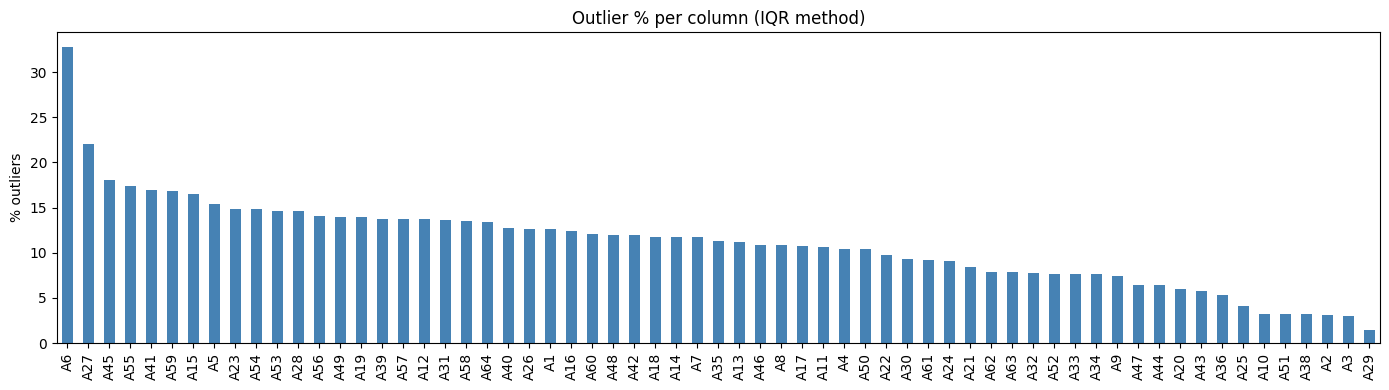

Total outlier cells: 54635 (11.1%)
Rows with at least 1 outlier: 7054 (90%)


In [81]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X_train < Q1 - 1.5 * IQR) | (X_train > Q3 + 1.5 * IQR)
outlier_pct = (outlier_mask.sum() / len(X_train) * 100).sort_values(ascending=False)

plt.figure(figsize=(14, 4))
outlier_pct.plot.bar(color='steelblue')
plt.title('Outlier % per column (IQR method)')
plt.ylabel('% outliers')
plt.tight_layout()
plt.show()

print(f"Total outlier cells: {outlier_mask.sum().sum()} ({100 * outlier_mask.sum().sum() / X_train.size:.1f}%)")
print(f"Rows with at least 1 outlier: {outlier_mask.any(axis=1).sum()} ({100 * outlier_mask.any(axis=1).mean():.0f}%)")

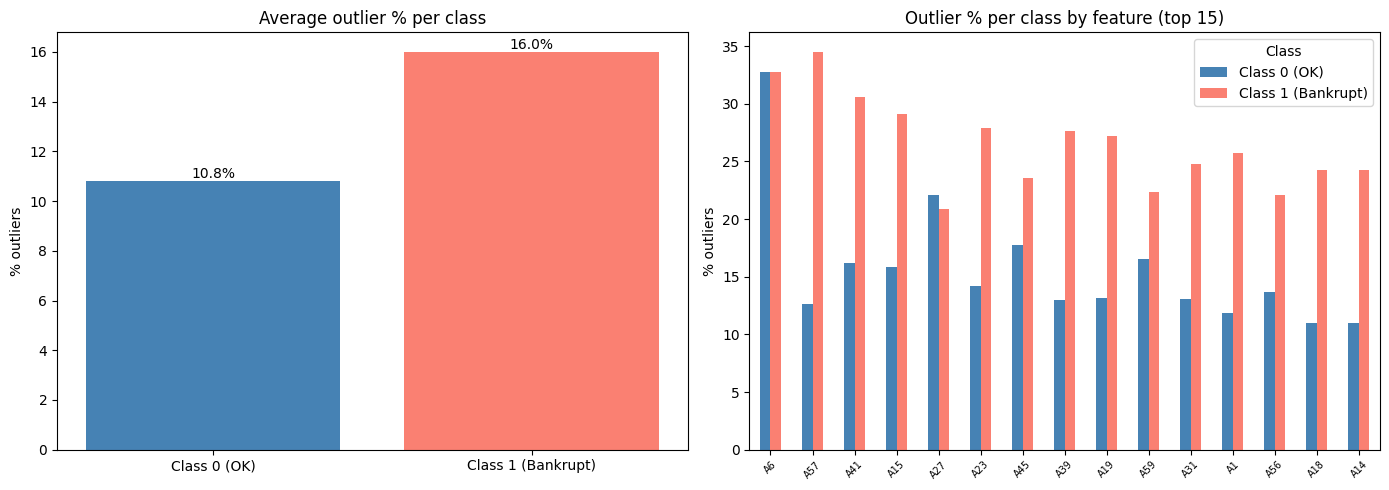

Total outlier cells: 54635 (11.1%)
Rows with at least 1 outlier: 7054 (90%)
Avg outliers per row — OK:       6.80
Avg outliers per row — Bankrupt: 10.07


In [82]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X_train < Q1 - 1.5 * IQR) | (X_train > Q3 + 1.5 * IQR)
outlier_pct = (outlier_mask.sum() / len(X_train) * 100).sort_values(ascending=False)

# Outlier % per feature per class
outlier_per_class = pd.DataFrame({
    'Class 0 (OK)':       outlier_mask[y_train.values == 0].mean() * 100,
    'Class 1 (Bankrupt)': outlier_mask[y_train.values == 1].mean() * 100,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lewy — średnia per klasa (analogicznie do missing values)
left_vals = outlier_per_class.mean()
axes[0].bar(left_vals.index.tolist(), left_vals.values, color=['steelblue', 'salmon'])
axes[0].set_title('Average outlier % per class')
axes[0].set_ylabel('% outliers')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')

# Prawy — top 15 cech z największym % outlierów
top_outlier_features = (
    outlier_per_class.mean(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)
outlier_per_class.loc[top_outlier_features].plot.bar(
    ax=axes[1],
    color=['steelblue', 'salmon']
)
axes[1].set_title('Outlier % per class by feature (top 15)')
axes[1].set_ylabel('% outliers')
axes[1].tick_params(axis='x', labelsize=7, rotation=45)
axes[1].legend(title='Class')

plt.tight_layout()
plt.show()

print(f"Total outlier cells: {outlier_mask.sum().sum()} ({100 * outlier_mask.sum().sum() / X_train.size:.1f}%)")
print(f"Rows with at least 1 outlier: {outlier_mask.any(axis=1).sum()} ({100 * outlier_mask.any(axis=1).mean():.0f}%)")
print(f"Avg outliers per row — OK:       {outlier_mask[y_train.values == 0].sum(axis=1).mean():.2f}")
print(f"Avg outliers per row — Bankrupt: {outlier_mask[y_train.values == 1].sum(axis=1).mean():.2f}")

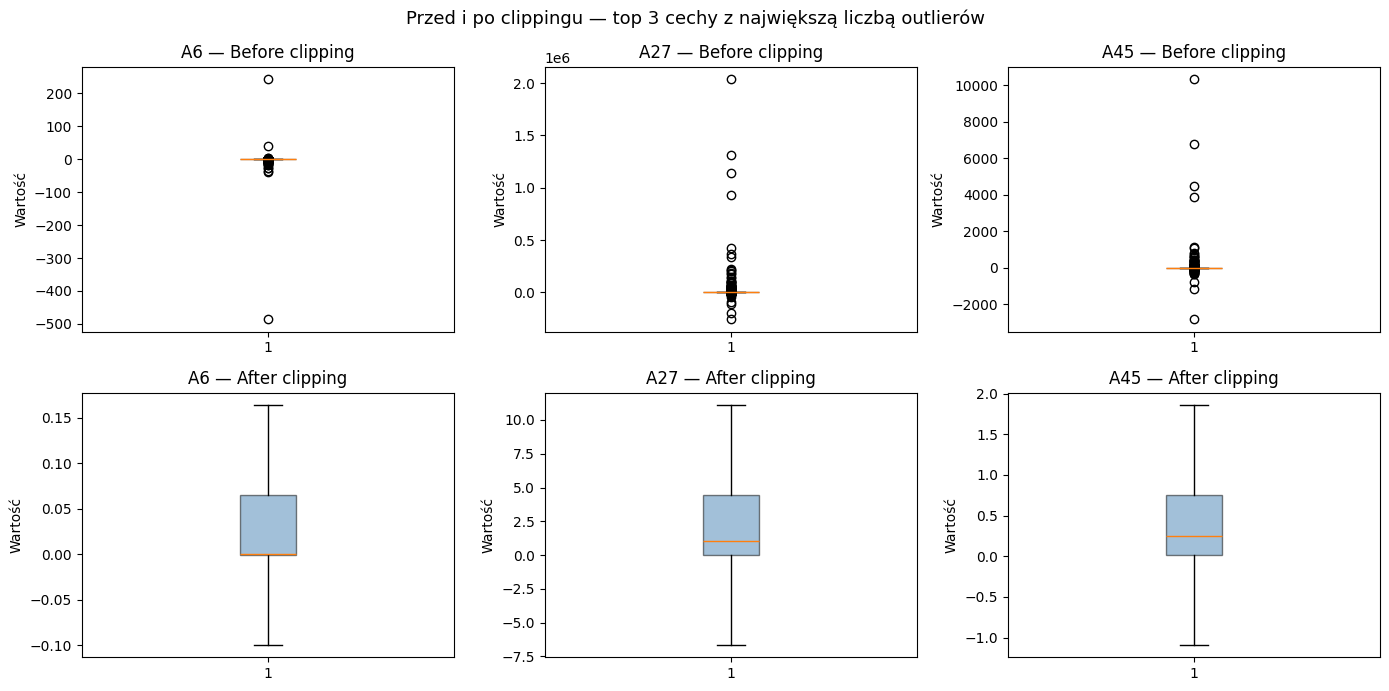

In [83]:
X_train_before_clip = X_train.copy()
X_test_before_clip = X_test.copy()

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Top 3 cechy z największym % outlierów
top3_cols = outlier_pct.head(3).index.tolist()

X_train_clipped = X_train.clip(lower=lower, upper=upper, axis=1)
X_test_clipped = X_test.clip(lower=lower, upper=upper, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for col_idx, col in enumerate(top3_cols):
    for row_idx, (data, title) in enumerate([
        (X_train[col], 'Before clipping'),
        (X_train_clipped[col], 'After clipping'),
    ]):
        ax = axes[row_idx, col_idx]
        ax.boxplot(data.dropna(), showfliers=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.5))
        ax.set_title(f'{col} — {title}')
        ax.set_ylabel('Wartość')

plt.suptitle('Przed i po clippingu — top 3 cechy z największą liczbą outlierów', fontsize=13)
plt.tight_layout()
plt.show()

In [84]:
# Właściwy clipping
X_train = X_train_clipped
X_test = X_test_clipped

print("Outlier cells after clipping:", ((X_train < lower) | (X_train > upper)).sum().sum())

Outlier cells after clipping: 0


### Standaryzacja 

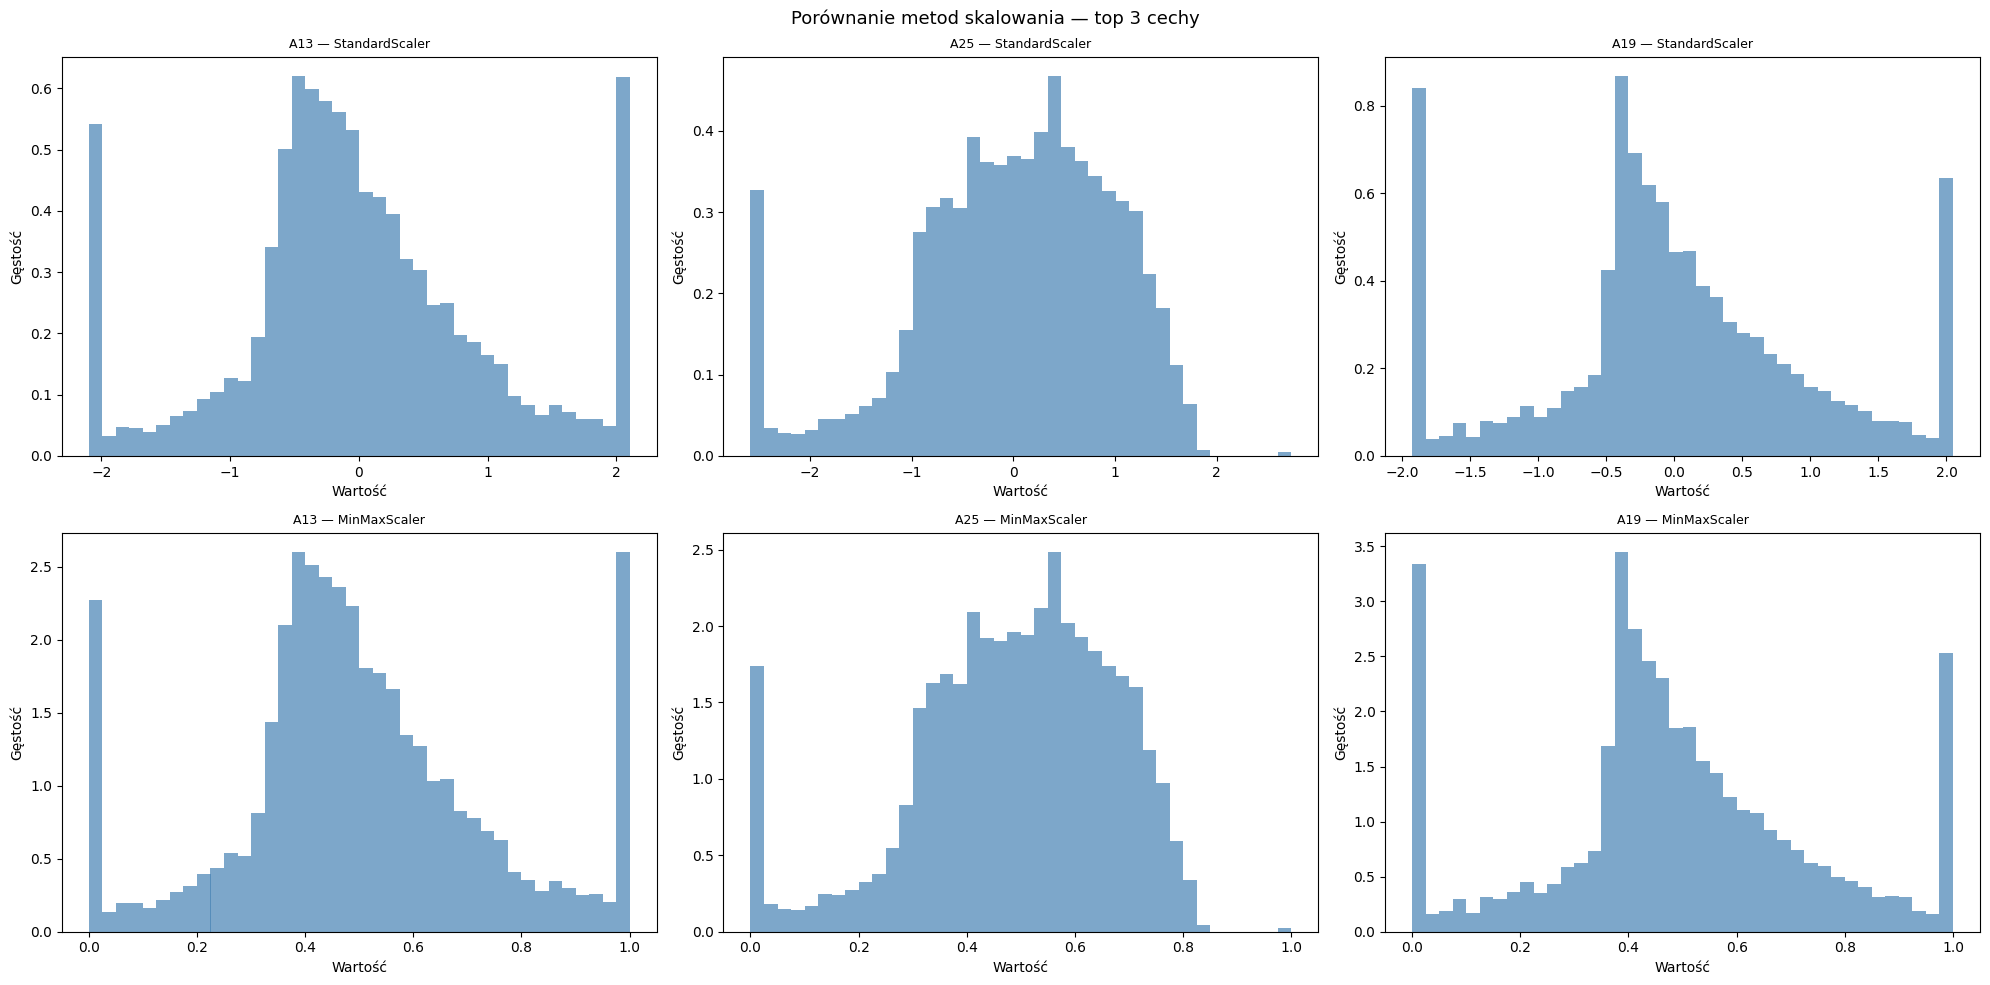

In [85]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
}

top3_cols = X_train.corrwith(y_train).abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for col_idx, col in enumerate(top3_cols):
    for row_idx, (name, scaler) in enumerate(scalers.items()):
        scaled = scaler.fit_transform(X_train[[col]])[:, 0]

        ax = axes[row_idx, col_idx]
        ax.hist(scaled, bins=40, color='steelblue', alpha=0.7, density=True)
        ax.set_title(f'{col} — {name}', fontsize=9)
        ax.set_xlabel('Wartość')
        ax.set_ylabel('Gęstość')

plt.suptitle('Porównanie metod skalowania — top 3 cechy', fontsize=13)
plt.tight_layout()
plt.show()

In [86]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### PCA i t-SNE

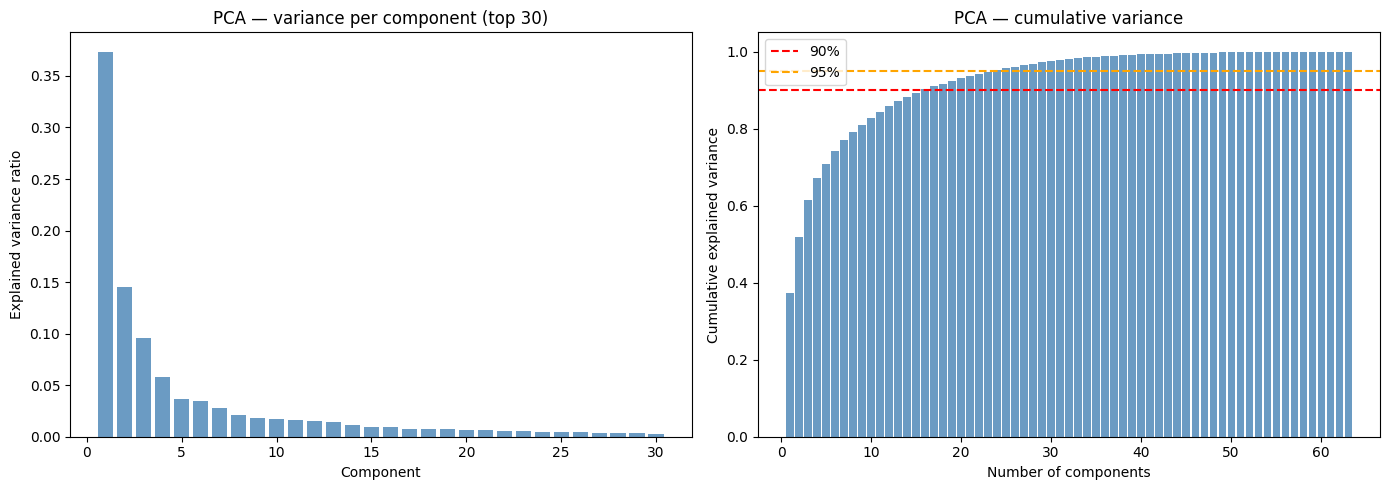

Components for 90%: 16
Components for 95%: 24
First 2 components: 51.8%


In [87]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumvar = pca_full.explained_variance_ratio_.cumsum()
var_ratio = pca_full.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lewy — histogram variance per component (pierwsze 30)
axes[0].bar(range(1, 31), var_ratio[:30], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('PCA — variance per component (top 30)')

# Prawy — skumulowana wariancja
axes[1].bar(range(1, len(cumvar)+1), cumvar, color='steelblue', alpha=0.8)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95%')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('PCA — cumulative variance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Components for 90%: {(cumvar >= 0.90).argmax() + 1}")
print(f"Components for 95%: {(cumvar >= 0.95).argmax() + 1}")
print(f"First 2 components: {cumvar[1]*100:.1f}%")

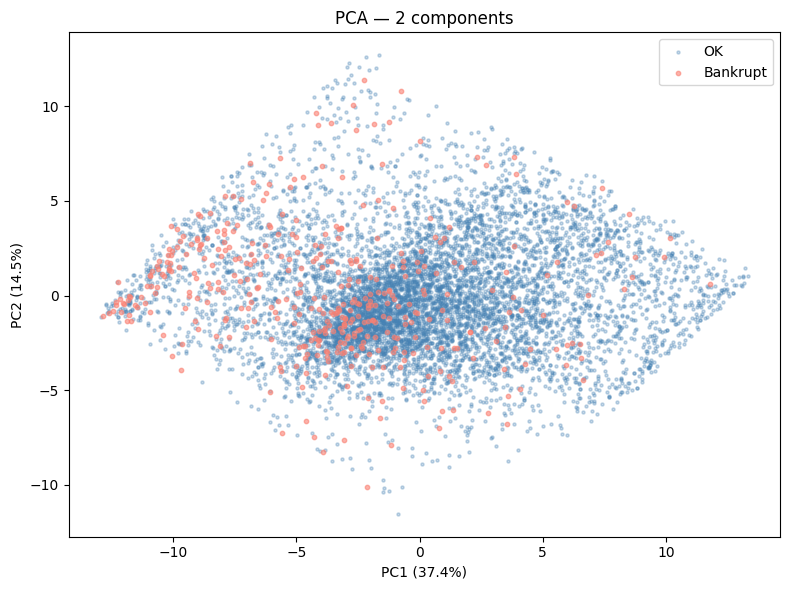

In [88]:
pca2 = PCA(n_components=2)
X_train_pca = pca2.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], c='salmon', alpha=0.6, s=10, label='Bankrupt')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — 2 components')
plt.legend()
plt.tight_layout()
plt.show()

### t-SNE

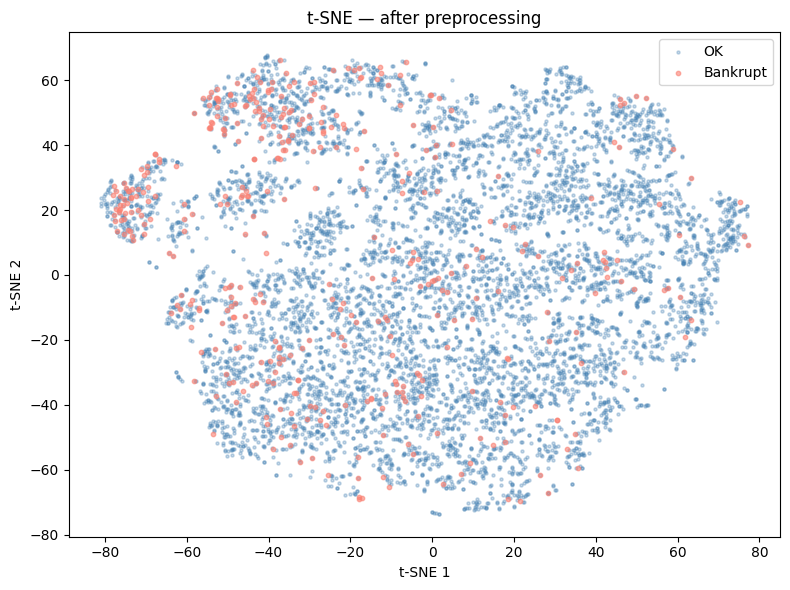

In [89]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[y_train == 0, 0], X_tsne[y_train == 0, 1], c='steelblue', alpha=0.3, s=5, label='OK')
plt.scatter(X_tsne[y_train == 1, 0], X_tsne[y_train == 1, 1], c='salmon', alpha=0.6, s=10, label='Bankrupt')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE — after preprocessing')
plt.legend()
plt.tight_layout()
plt.show()

### Modelowanie

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, make_scorer

scoring = {
    'f1':        make_scorer(f1_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score, zero_division=0),
    'accuracy':  make_scorer(accuracy_score),
}

# --- Random Forest ---
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth':    [5, 10, None],
    'class_weight': ['balanced', None],
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf,
                       scoring=scoring,
                       refit='f1', cv=5, n_jobs=-1, verbose=1)
grid_rf.fit(X_train_scaled, y_train)

y_pred_rf = grid_rf.predict(X_test_scaled)
print(f"=== Random Forest ===")
print(f"Best params: {grid_rf.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, zero_division=0):.3f}")
print(f"F1:        {f1_score(y_test, y_pred_rf, zero_division=0):.3f}")

# --- Logistic Regression ---
param_grid_lr = {
    'C':            [0.01, 0.1, 1, 10],
    'class_weight': ['balanced', None],
    'solver':       ['lbfgs'],
    'max_iter':     [1000],
}

lr = LogisticRegression(random_state=42)
grid_lr = GridSearchCV(lr, param_grid_lr,
                       scoring=scoring,
                       refit='f1', cv=5, n_jobs=-1, verbose=1)
grid_lr.fit(X_train_scaled, y_train)

y_pred_lr = grid_lr.predict(X_test_scaled)
print(f"\n=== Logistic Regression ===")
print(f"Best params: {grid_lr.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr, zero_division=0):.3f}")
print(f"F1:        {f1_score(y_test, y_pred_lr, zero_division=0):.3f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
=== Random Forest ===
Best params: {'class_weight': 'balanced', 'max_depth': 5, 'n_estimators': 100}
Accuracy:  0.847
Precision: 0.194
Recall:    0.602
F1:        0.293
Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Logistic Regression ===
Best params: {'C': 10, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs'}
Accuracy:  0.765
Precision: 0.133
Recall:    0.631
F1:        0.220


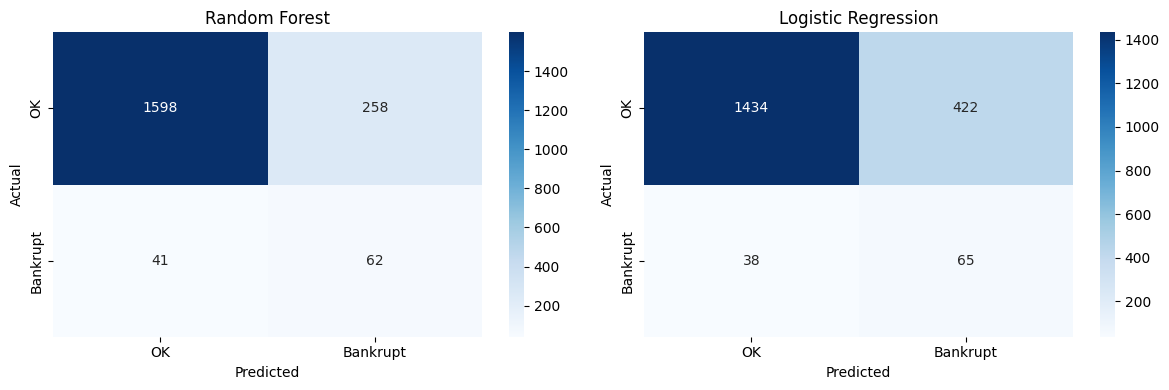

In [91]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, name in zip(axes, [y_pred_rf, y_pred_lr], ['Random Forest', 'Logistic Regression']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['OK', 'Bankrupt'],
                yticklabels=['OK', 'Bankrupt'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.tight_layout()
plt.show()

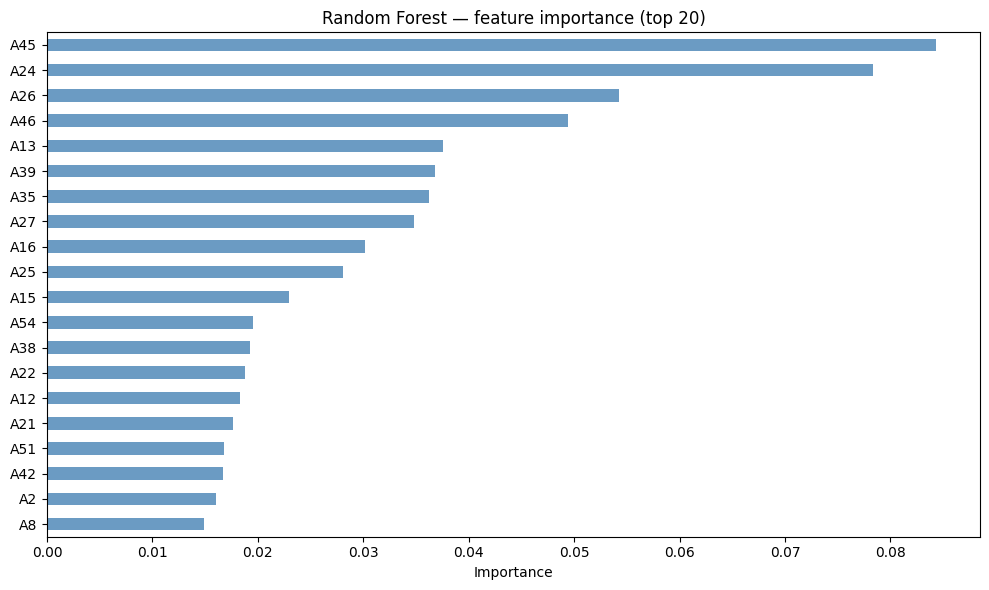

In [92]:
importances = pd.Series(grid_rf.best_estimator_.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot.barh(color='steelblue', alpha=0.8)
plt.title('Random Forest — feature importance (top 20)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

                     Accuracy  Precision  Recall
Clipping + Standard      0.77       0.13    0.63
Clipping + MinMax        0.75       0.13    0.63
No clip + Standard       0.77       0.13    0.56
No clip + MinMax         0.68       0.08    0.51


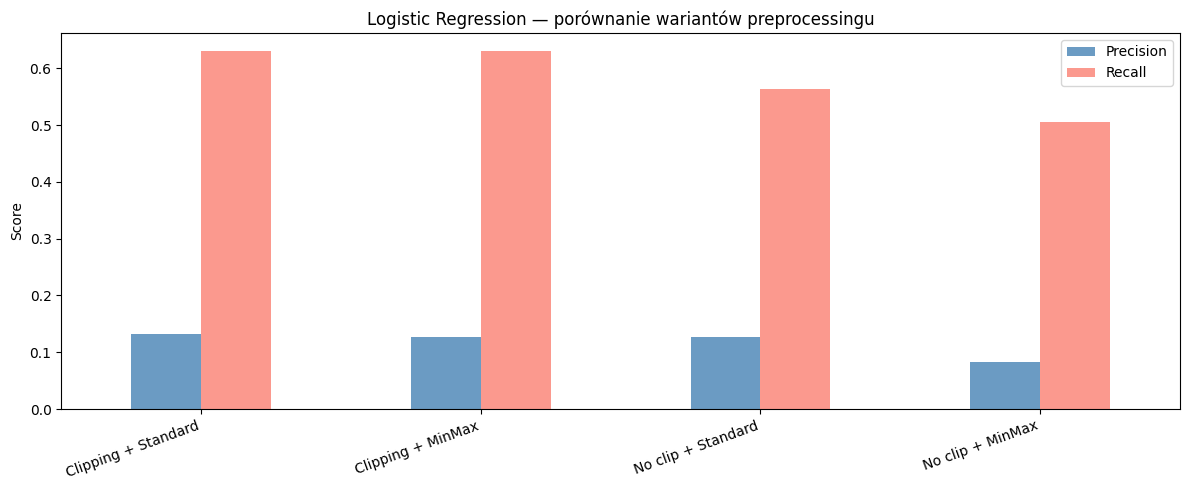

In [93]:
from sklearn.preprocessing import MinMaxScaler

X_train_clip_minmax = MinMaxScaler().fit_transform(X_train)
X_test_clip_minmax = MinMaxScaler().fit(X_train).transform(X_test)

results = {}

variants = {
    'Clipping + Standard': (X_train_scaled, X_test_scaled),
    'Clipping + MinMax':   (X_train_clip_minmax, X_test_clip_minmax),
    'No clip + Standard':  (
        StandardScaler().fit_transform(X_train_before_clip),
        StandardScaler().fit(X_train_before_clip).transform(X_test_before_clip)
    ),
    'No clip + MinMax': (
        MinMaxScaler().fit_transform(X_train_before_clip),
        MinMaxScaler().fit(X_train_before_clip).transform(X_test_before_clip)
    ),
}

for variant_name, (X_tr, X_te) in variants.items():
    model = LogisticRegression(random_state=42)
    model.set_params(**{k: v for k, v in grid_lr.best_params_.items() if k in model.get_params()})
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    results[variant_name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
    }

results_df = pd.DataFrame(results).T.round(3)
print(results_df.to_string())

results_df[['Precision', 'Recall']].plot.bar(
    figsize=(12, 5), color=['steelblue', 'salmon'], alpha=0.8
)
plt.title('Logistic Regression — porównanie wariantów preprocessingu')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

                  Accuracy  Precision  Recall
Median global         0.84       0.18    0.57
Median per class      0.85       0.19    0.60
KNN                   0.83       0.17    0.55


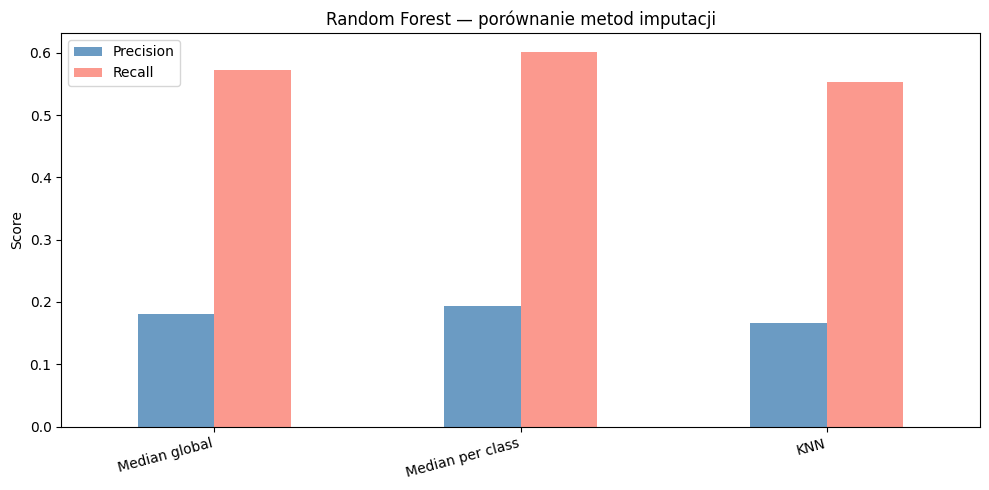

In [94]:
# Potrzebujemy danych przed imputacją — dodaj tę linię przed komórką z imputacją jeśli nie masz
# X_train_raw = X_train.copy()  # przed jakąkolwiek imputacją

# Globalna mediana
imp_global = SimpleImputer(strategy='median')
X_tr_global = pd.DataFrame(imp_global.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_te_global = pd.DataFrame(imp_global.transform(X_test_raw), columns=X_test_raw.columns)

# Mediana per klasa
def impute_per_class(X_tr, X_te, y_tr, y_te):
    X_tr = X_tr.copy().reset_index(drop=True)
    X_te = X_te.copy().reset_index(drop=True)
    y_tr = y_tr.reset_index(drop=True)
    y_te = y_te.reset_index(drop=True)
    class_medians = {}
    global_med = X_tr.median()
    for cls in [0, 1]:
        mask = pd.Series(y_tr.values == cls, index=X_tr.index)
        class_medians[cls] = X_tr.loc[mask].median()
    for cls in [0, 1]:
        for col in X_tr.columns:
            fill = class_medians[cls][col] if pd.notna(class_medians[cls][col]) else global_med[col]
            mask_tr = pd.Series(y_tr.values == cls, index=X_tr.index)
            X_tr.loc[mask_tr & X_tr[col].isna(), col] = fill
            mask_te = pd.Series(y_te.values == cls, index=X_te.index)
            X_te.loc[mask_te & X_te[col].isna(), col] = fill
    return X_tr, X_te

X_tr_perclass, X_te_perclass = impute_per_class(X_train_raw, X_test_raw, y_train, y_test)

# KNN
imp_knn = KNNImputer(n_neighbors=5)
X_tr_knn = pd.DataFrame(imp_knn.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_te_knn = pd.DataFrame(imp_knn.transform(X_test_raw), columns=X_test_raw.columns)

results_imp = {}
scaler_imp = StandardScaler()

for name, (X_tr, X_te) in [
    ('Median global',    (X_tr_global,   X_te_global)),
    ('Median per class', (X_tr_perclass, X_te_perclass)),
    ('KNN',              (X_tr_knn,      X_te_knn)),
]:
    # Clipping + scaling identyczny jak w głównym pipeline
    Q1_ = X_tr.quantile(0.25); Q3_ = X_tr.quantile(0.75); IQR_ = Q3_ - Q1_
    X_tr_c = X_tr.clip(lower=Q1_ - 1.5*IQR_, upper=Q3_ + 1.5*IQR_, axis=1)
    X_te_c = X_te.clip(lower=Q1_ - 1.5*IQR_, upper=Q3_ + 1.5*IQR_, axis=1)
    X_tr_s = scaler_imp.fit_transform(X_tr_c)
    X_te_s = scaler_imp.transform(X_te_c)

    model = RandomForestClassifier(random_state=42)
    model.set_params(**{k: v for k, v in grid_rf.best_params_.items() if k in model.get_params()})
    model.fit(X_tr_s, y_train)
    y_pred = model.predict(X_te_s)
    results_imp[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
    }

results_imp_df = pd.DataFrame(results_imp).T.round(3)
print(results_imp_df.to_string())

results_imp_df[['Precision', 'Recall']].plot.bar(
    figsize=(10, 5), color=['steelblue', 'salmon'], alpha=0.8
)
plt.title('Random Forest — porównanie metod imputacji')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA

n_90 = (pca_full.explained_variance_ratio_.cumsum() >= 0.90).argmax() + 1
n_95 = (pca_full.explained_variance_ratio_.cumsum() >= 0.95).argmax() + 1

results_pca = {}

variants_pca = {
    'No PCA':       X_train_scaled,
    f'PCA 90% ({n_90} comp)': PCA(n_components=n_90).fit_transform(X_train_scaled),
    f'PCA 95% ({n_95} comp)': PCA(n_components=n_95).fit_transform(X_train_scaled),
    'PCA 2 comp':   PCA(n_components=2).fit_transform(X_train_scaled),
}

variants_pca_test = {
    'No PCA':       X_test_scaled,
    f'PCA 95% ({n_95} comp)': PCA(n_components=n_95).fit(X_train_scaled).transform(X_test_scaled),
    f'PCA 90% ({n_90} comp)': PCA(n_components=n_90).fit(X_train_scaled).transform(X_test_scaled),
    'PCA 2 comp':   PCA(n_components=2).fit(X_train_scaled).transform(X_test_scaled),
}

for name in variants_pca:
    model = RandomForestClassifier(random_state=42)
    model.set_params(**{k: v for k, v in grid_rf.best_params_.items() if k in model.get_params()})
    model.fit(variants_pca[name], y_train)
    y_pred = model.predict(variants_pca_test[name])
    results_pca[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
    }

results_pca_df = pd.DataFrame(results_pca).T.round(3)
print(results_pca_df.to_string())

results_pca_df[['Precision', 'Recall']].plot.bar(
    figsize=(10, 5), color=['steelblue', 'salmon'], alpha=0.8
)
plt.title('Random Forest — porównanie wariantów PCA')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()